# Part 2 : Non linear model

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# graphe pour le rapport final
from yellowbrick.model_selection import ValidationCurve, LearningCurve
from yellowbrick.model_selection import FeatureImportances
from yellowbrick.regressor import ResidualsPlot, PredictionError

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, KFold, validation_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Importation des données

In [21]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv', header=None).values.ravel()
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv', header=None).values.ravel()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1000, 14), Test: (500, 14)


## Préprocessing

In [22]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Custom transformer pour retirer img_filename
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=self.columns)

categorical_cols = ['profession', 'sarsaparilla', 'smurfberry liquor', 'smurfin donuts']
numerical_cols = ['age', 'blood pressure', 'calcium', 'cholesterol', 
                  'hemoglobin', 'height', 'potassium', 'vitamin D', 'weight']

# Pipeline de preprocessing
preprocessing_pipeline = Pipeline([
    ('drop_img', DropColumns(columns=['img_filename'])),
    ('preprocessor', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 
         categorical_cols)
    ]))
])

X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)
feature_names = numerical_cols + categorical_cols

print("Preprocessing done")

Preprocessing done


### ============================================================================
## FEATURE SELECTION - Comparaison de plusieurs méthodes
### ============================================================================


Top features (Corrélation):
  blood pressure      : 0.659
  cholesterol         : 0.449
  weight              : 0.418
  age                 : 0.221
  hemoglobin          : 0.161
  height              : 0.111
  sarsaparilla        : 0.066

Top features (Mutual Information):
  blood pressure      : 0.244
  cholesterol         : 0.101
  weight              : 0.086
  smurfin donuts      : 0.078
  potassium           : 0.063
  vitamin D           : 0.048
  profession          : 0.042

Top features (Random Forest):
  blood pressure      : 0.578
  hemoglobin          : 0.112
  potassium           : 0.094
  weight              : 0.043
  age                 : 0.038
  cholesterol         : 0.034
  height              : 0.026


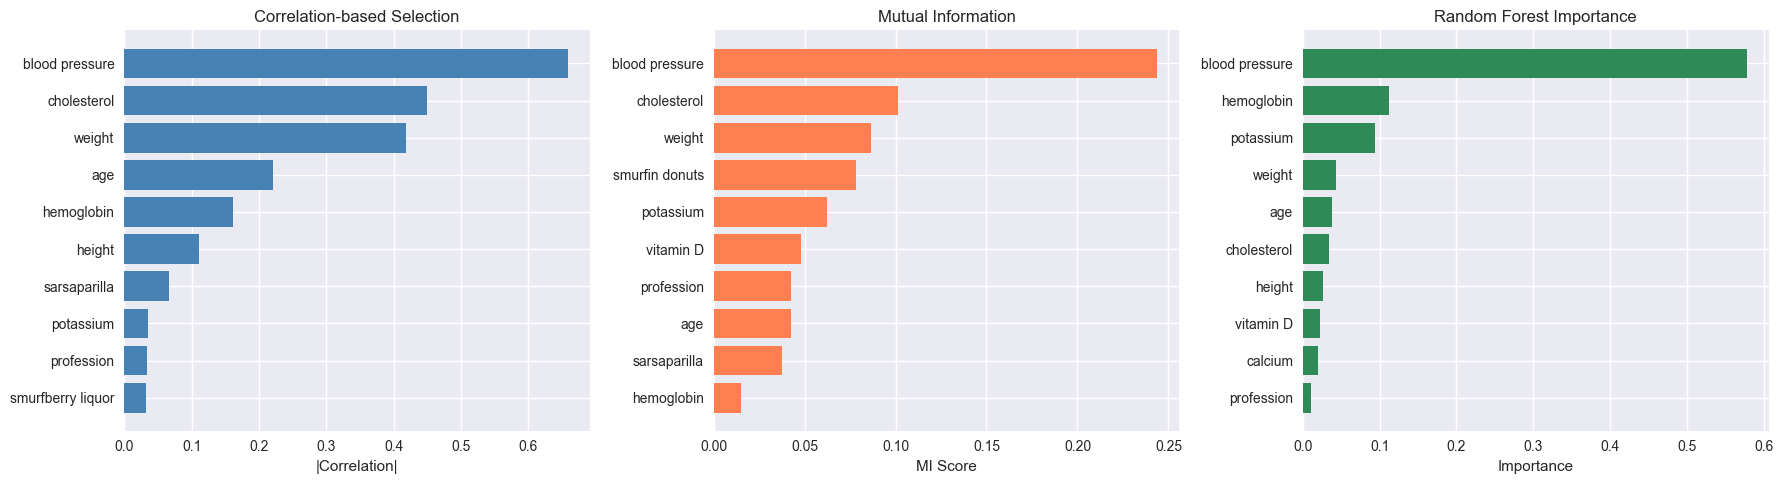


Features sélectionnées (11): ['weight', 'smurfin donuts', 'profession', 'cholesterol', 'blood pressure', 'hemoglobin', 'vitamin D', 'potassium', 'height', 'age', 'sarsaparilla']


In [23]:
# 1. Correlation-based selection
correlations = []
for i, col in enumerate(feature_names):
    corr = np.corrcoef(X_train_scaled[:, i], y_train)[0, 1]
    correlations.append((col, abs(corr)))
correlations.sort(key=lambda x: x[1], reverse=True)

print("\nTop features (Corrélation):")
for name, corr in correlations[:7]:
    print(f"  {name:20s}: {corr:.3f}")

# 2. Mutual Information
mi_scores = mutual_info_regression(X_train_scaled, y_train, random_state=42)
mi_ranking = sorted(zip(feature_names, mi_scores), key=lambda x: x[1], reverse=True)

print("\nTop features (Mutual Information):")
for name, score in mi_ranking[:7]:
    print(f"  {name:20s}: {score:.3f}")

# 3. Random Forest Feature Importance
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)
importances = sorted(zip(feature_names, rf_selector.feature_importances_), 
                     key=lambda x: x[1], reverse=True)

print("\nTop features (Random Forest):")
for name, imp in importances[:7]:
    print(f"  {name:20s}: {imp:.3f}")

# Visualisation des importances
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation
corr_df = pd.DataFrame(correlations[:10], columns=['Feature', 'Score'])
axes[0].barh(corr_df['Feature'], corr_df['Score'], color='steelblue')
axes[0].set_xlabel('|Correlation|')
axes[0].set_title('Correlation-based Selection')
axes[0].invert_yaxis()

# Mutual Information
mi_df = pd.DataFrame(mi_ranking[:10], columns=['Feature', 'Score'])
axes[1].barh(mi_df['Feature'], mi_df['Score'], color='coral')
axes[1].set_xlabel('MI Score')
axes[1].set_title('Mutual Information')
axes[1].invert_yaxis()

# Random Forest
imp_df = pd.DataFrame(importances[:10], columns=['Feature', 'Score'])
axes[2].barh(imp_df['Feature'], imp_df['Score'], color='seagreen')
axes[2].set_xlabel('Importance')
axes[2].set_title('Random Forest Importance')
axes[2].invert_yaxis()

plt.tight_layout()
#plt.savefig('feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Sélection des top features (consensus)
top_features = list(set([f[0] for f in correlations[:7]] + 
                       [f[0] for f in mi_ranking[:7]] + 
                       [f[0] for f in importances[:7]]))

print(f"\nFeatures sélectionnées ({len(top_features)}): {top_features}")

feature_indices = [feature_names.index(f) for f in top_features]
X_train_selected = X_train_scaled[:, feature_indices]
X_test_selected = X_test_scaled[:, feature_indices]

### ============================================================================
## MODÈLES NON-LINÉAIRES - Training et comparaison
### ============================================================================



Decision Tree...
  CV RMSE: 0.0605 ± 0.0038
  Test RMSE: 0.0575

Random Forest...
  CV RMSE: 0.0444 ± 0.0023
  Test RMSE: 0.0461

Gradient Boosting...
  CV RMSE: 0.0424 ± 0.0015
  Test RMSE: 0.0429

AdaBoost...
  CV RMSE: 0.0526 ± 0.0018
  Test RMSE: 0.0529

SVR (RBF)...
  CV RMSE: 0.0611 ± 0.0025
  Test RMSE: 0.0579

KNN...
  CV RMSE: 0.0583 ± 0.0052
  Test RMSE: 0.0582

MLP...
  CV RMSE: 0.0889 ± 0.0032
  Test RMSE: 0.0877

RÉSULTATS DES MODÈLES
                   cv_rmse_mean  cv_rmse_std  train_rmse  test_rmse  test_r2  \
Gradient Boosting        0.0424       0.0015      0.0270     0.0429   0.7269   
Random Forest            0.0444       0.0023      0.0168     0.0461   0.6848   
AdaBoost                 0.0526       0.0018      0.0477     0.0529   0.5842   
Decision Tree            0.0605       0.0038      0.0000     0.0575   0.5087   
SVR (RBF)                0.0611       0.0025      0.0574     0.0579   0.5031   
KNN                      0.0583       0.0052      0.0468     0.0582

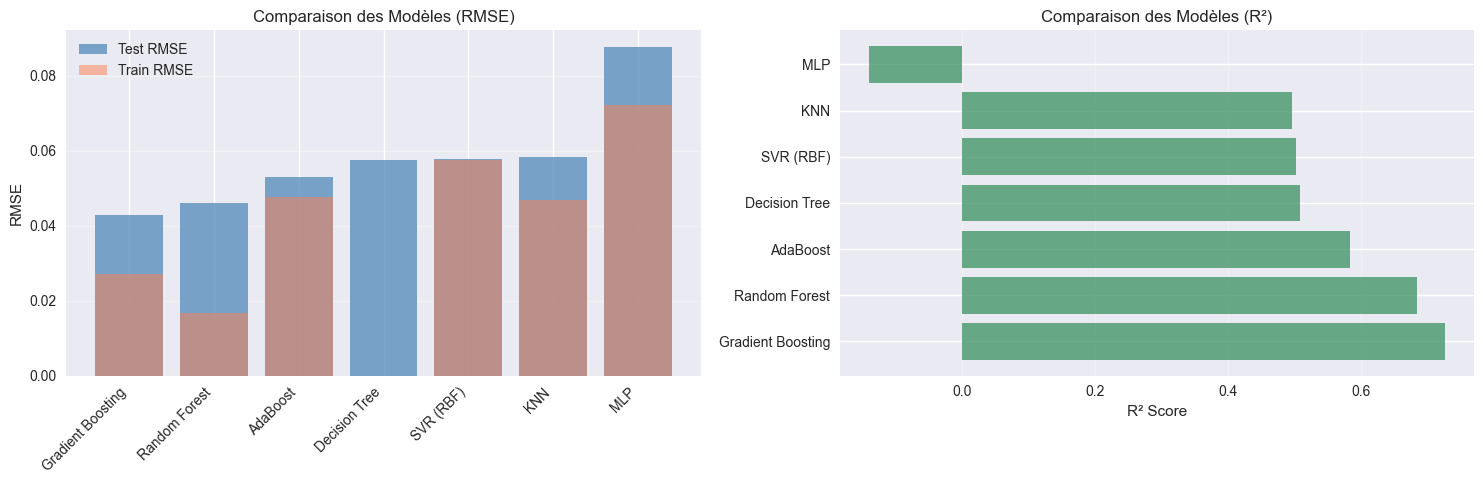

In [24]:
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'SVR (RBF)': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'MLP': MLPRegressor(random_state=42, max_iter=1000)
}

results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{name}...")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_selected, y_train, 
                                cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores)
    
    # Entraînement sur tout le train set
    model.fit(X_train_selected, y_train)
    
    # Prédictions
    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)
    
    # Métriques
    results[name] = {
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std(),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'test_r2': r2_score(y_test, y_pred_test),
        'test_mae': mean_absolute_error(y_test, y_pred_test)
    }
    
    print(f"  CV RMSE: {results[name]['cv_rmse_mean']:.4f} ± {results[name]['cv_rmse_std']:.4f}")
    print(f"  Test RMSE: {results[name]['test_rmse']:.4f}")

# Tableau récapitulatif
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('test_rmse')
print("\n" + "="*60)
print("RÉSULTATS DES MODÈLES")
print("="*60)
print(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))



# RMSE comparison
model_names = results_df.index
x_pos = np.arange(len(model_names))
axes[0].bar(x_pos, results_df['test_rmse'], alpha=0.7, color='steelblue', label='Test RMSE')
axes[0].bar(x_pos, results_df['train_rmse'], alpha=0.5, color='coral', label='Train RMSE')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Comparaison des Modèles (RMSE)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R^2 comparison
axes[1].barh(model_names, results_df['test_r2'], color='seagreen', alpha=0.7)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Comparaison des Modèles (R²)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
#plt.savefig('models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

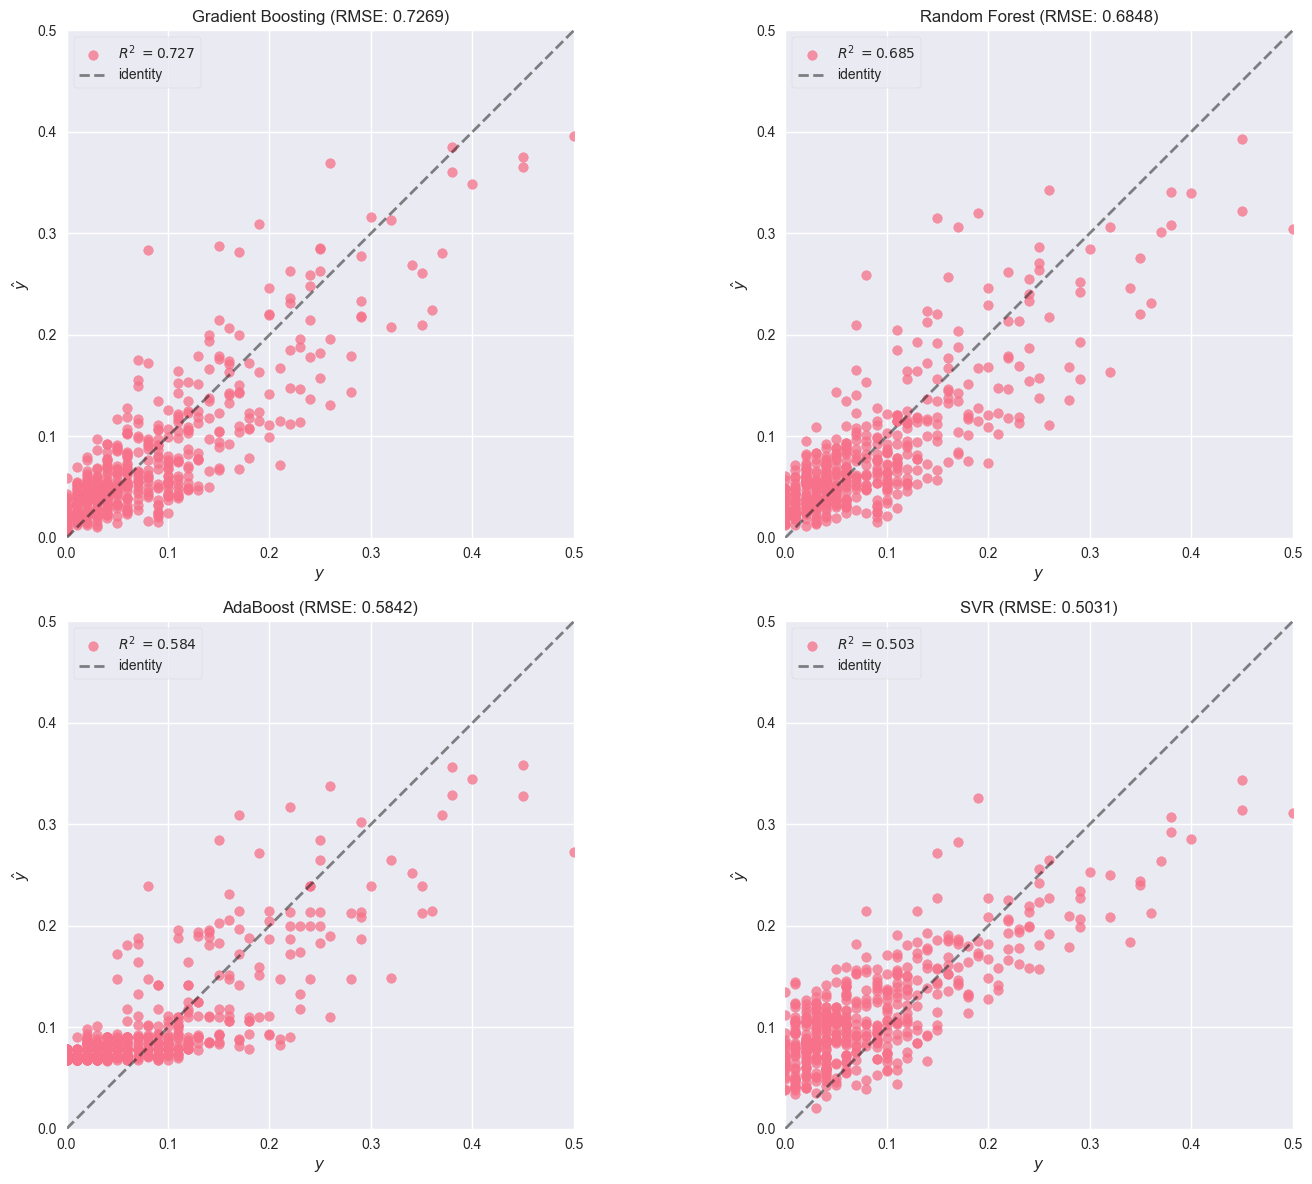

In [25]:
from yellowbrick.regressor import PredictionError

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
models_to_compare = [
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('AdaBoost', AdaBoostRegressor(random_state=42)),
    ('SVR', SVR(kernel='rbf'))
]

for idx, (name, model) in enumerate(models_to_compare):
    ax = axes[idx // 2, idx % 2]
    
    viz = PredictionError(model, ax=ax, identity=True, bestfit=False)
    viz.fit(X_train_selected, y_train)
    viz.score(X_test_selected, y_test)
    viz.finalize()
    ax.set_title(f'{name} (RMSE: {viz.score_:.4f})')

plt.tight_layout()
#plt.savefig('models_comparison_yb.png', dpi=300, bbox_inches='tight')
plt.show()

### ============================================================================
## HYPERPARAMETER TUNING - Meilleur modèle
### ============================================================================



Learning Curve - Gradient Boosting


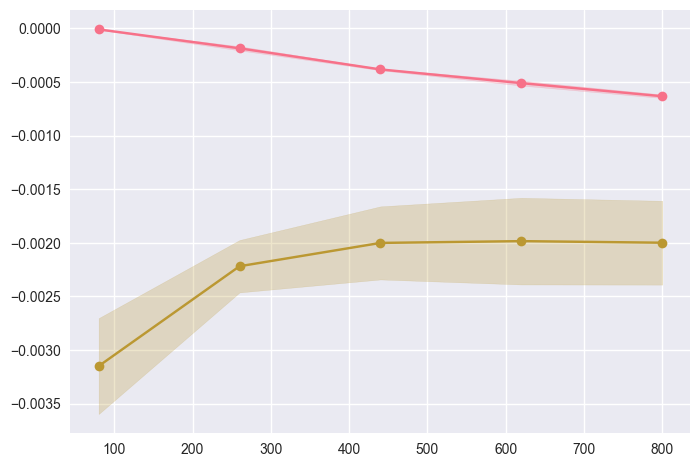

In [26]:
# ============================================================================
# LEARNING CURVE - Pour détecter overfitting et besoin de plus de données
# ============================================================================
print("\nLearning Curve - Gradient Boosting")

viz_learn = LearningCurve(
    GradientBoostingRegressor(random_state=42),
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

viz_learn.fit(X_train_scaled, y_train)
#viz_learn.show(outpath="learning_curve_gb.png")
plt.show()

In [27]:
best_model_name = results_df.index[0]

# Créer une pipeline complète
if 'Random Forest' in best_model_name:
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_split': [8, 12, 16],
        'model__min_samples_leaf': [10, 15, 20],
        'model__max_features': ['sqrt', 'log2']
    }
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    
elif 'Gradient Boosting' in best_model_name:
    param_grid = {
        'model__n_estimators': [100, 125, 150, 200, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 9],
        'model__min_samples_split': [8, 12, 16],
        'model__subsample': [0.8, 1.0]
    }
    base_model = GradientBoostingRegressor(random_state=42)
    
elif 'SVR' in best_model_name:
    param_grid = {
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto', 0.01, 0.1],
        'model__epsilon': [0.01, 0.1, 0.2]
    }
    base_model = SVR(kernel='rbf')
    
else:
    print("Pas de tuning spécifique pour ce modèle")
    param_grid = {}
    base_model = models[best_model_name]

# Pipeline complète avec preprocessing intégré
full_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', base_model)
])

if param_grid:
    grid_search = GridSearchCV(
        full_pipeline, 
        param_grid, 
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit directement sur les données brutes
    grid_search.fit(X_train, y_train)
    
    print(f"\nMeilleurs hyperparamètres:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    
    best_pipeline = grid_search.best_estimator_
else:
    best_pipeline = full_pipeline
    best_pipeline.fit(X_train, y_train)

# Évaluation finale (directement sur données brutes)
y_pred_train_final = best_pipeline.predict(X_train)
y_pred_test_final = best_pipeline.predict(X_test)


print(f"\n" + "="*60)
print(f"PERFORMANCE FINALE DU MODÈLE OPTIMISÉ : {best_model_name}")
print("="*60)
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_final)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_final)):.4f}")
print(f"Test R²:    {r2_score(y_test, y_pred_test_final):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_pred_test_final):.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Meilleurs hyperparamètres:
  model__learning_rate: 0.05
  model__max_depth: 3
  model__min_samples_split: 12
  model__n_estimators: 300
  model__subsample: 0.8

PERFORMANCE FINALE DU MODÈLE OPTIMISÉ : Gradient Boosting
Train RMSE: 0.0230
Test RMSE:  0.0417
Test R²:    0.7423
Test MAE:   0.0316



Validation Curve - Gradient Boosting (n_estimators)


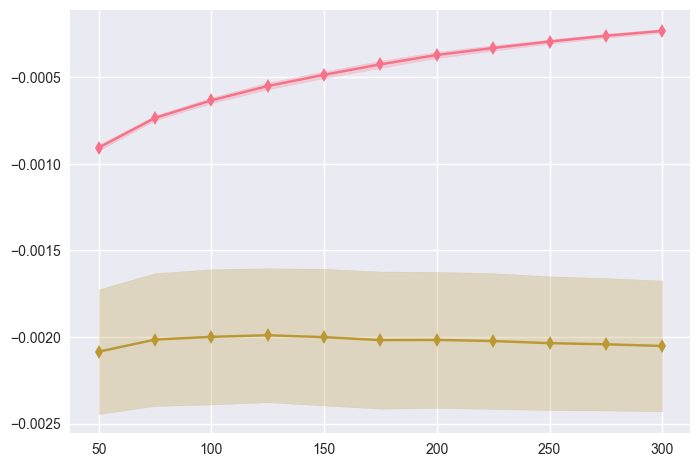


   Validation Curve - Random Forest (max_depth)


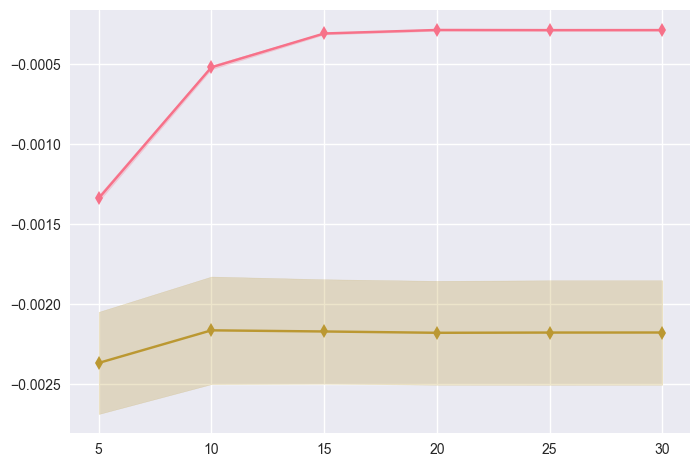

In [28]:
# ============================================================================
# VALIDATION CURVE - Pour analyser l'impact d'un hyperparamètre
# ============================================================================
print("\nValidation Curve - Gradient Boosting (n_estimators)")

viz_val = ValidationCurve(
    GradientBoostingRegressor(random_state=42),
    param_name="n_estimators",
    param_range=np.arange(50, 301, 25),
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

viz_val.fit(X_train_scaled, y_train)
#viz_val.show(outpath="validation_curve_gb.png")
plt.show()

# Pour Random Forest aussi
print("\n   Validation Curve - Random Forest (max_depth)")

viz_val_rf = ValidationCurve(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_name="max_depth",
    param_range=np.arange(5, 31, 5),
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

viz_val_rf.fit(X_train_scaled, y_train)
#viz_val_rf.show(outpath="validation_curve_rf.png")
plt.show()


Residuals Plot


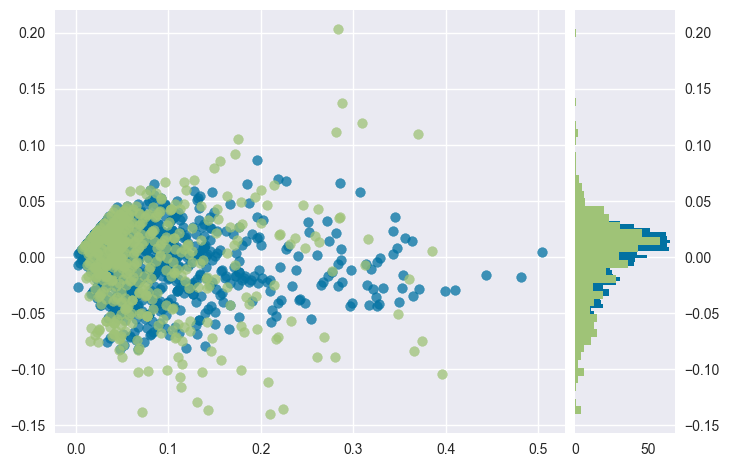

In [29]:
print("\nResiduals Plot")

viz_resid = ResidualsPlot(
    base_model,  # Ton meilleur modèle après tuning
    hist=True
)

viz_resid.fit(X_train_selected, y_train)
viz_resid.score(X_test_selected, y_test)
#viz_resid.show(outpath="residuals_plot.png")
plt.show()


 Prediction Error Plot


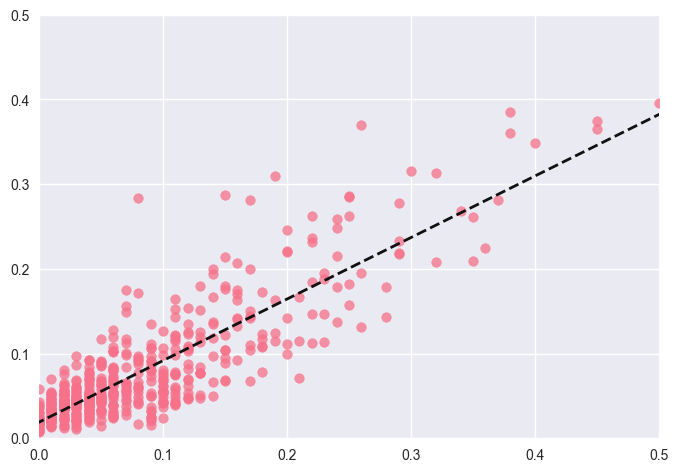

In [30]:
print("\n Prediction Error Plot")

viz_pred = PredictionError(
    base_model,
    identity=True,  # Ligne 45 degrés
    bestfit=True    # Ligne de meilleur fit
)

viz_pred.fit(X_train_selected, y_train)
viz_pred.score(X_test_selected, y_test)
#viz_pred.show(outpath="prediction_error_plot.png")
plt.show()